In [ ]:
# -----------------------------------
#  Imports and Global Config
# -----------------------------------
import os
import random
import time
import tracemalloc
import json
import matplotlib.pyplot as plt
import pandas as pd

random.seed(42)
MIN_REST_HOURS = 1
NUM_CREW = 3
CREW_LIST = [f"CR{idx+1}" for idx in range(NUM_CREW)]

OUT_DIR = "aircrew_outputs_rewritten"
os.makedirs(OUT_DIR, exist_ok=True)


In [ ]:
# -----------------------------------
#   Flight Generator
# -----------------------------------
def make_flights_random(k):
    """
    Generate k flights as (id, start, end).
    """
    flights = []
    for i in range(k):
        start = random.randint(6, 20)
        duration = random.randint(1, 3)
        end = start + duration
        flights.append((f"FL{i+1}", start, end))
    return flights


In [ ]:
# -----------------------------------
# Check if a crew can take a flight
# -----------------------------------
def crew_can_take(assigned_list, flight_id, times_map, rest=MIN_REST_HOURS):
    """
    Check overlap + required rest time.
    """
    new_s, new_e = times_map[flight_id]

    for fid in assigned_list:
        s, e = times_map[fid]

        if not (new_e + rest <= s or e + rest <= new_s):
            return False

    return True


In [ ]:
def solve_all_assignments(current_alloc, remaining_flights, times_map,
                          rest=MIN_REST_HOURS, stats=None):
    """
    Backtracking to assign all flights.
    """
    if stats is None:
        stats = {'calls': 0}
    stats['calls'] += 1

    if not remaining_flights:
        return [{c: assigned[:] for c, assigned in current_alloc.items()}]

    solutions = []
    flight = remaining_flights[0]
    rest_list = remaining_flights[1:]

    for crew in current_alloc:
        if crew_can_take(current_alloc[crew], flight, times_map, rest):
            current_alloc[crew].append(flight)
            sols = solve_all_assignments(current_alloc, rest_list, times_map, rest, stats)
            solutions.extend(sols)
            current_alloc[crew].pop()

    return solutions


In [ ]:
def run_trials(flight_range):
    summary = []

    for n in flight_range:
        flights = make_flights_random(n)
        times_map = {fid: (s, e) for fid, s, e in flights}
        flight_ids = [fid for fid, _, _ in flights]

        tracemalloc.start()
        t0 = time.perf_counter()

        stats = {'calls': 0}
        sols = solve_all_assignments({c: [] for c in CREW_LIST},
                                     flight_ids, times_map, MIN_REST_HOURS, stats)

        t1 = time.perf_counter()
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        summary.append({
            "n": n,
            "time": t1 - t0,
            "calls": stats['calls'],
            "solutions": len(sols),
            "mem_peak": peak
        })

        print(f"[n={n}] time={t1-t0:.4f}s calls={stats['calls']} "
              f"solutions={len(sols)} mem_peak={peak}")

    return summary


In [ ]:
flight_counts = range(4, 11)
results = run_trials(flight_counts)

df = pd.DataFrame(results)
df.to_csv(os.path.join(OUT_DIR, "experiment_table_rewritten.csv"), index=False)

df


[n=4] time=0.0007s calls=76 solutions=36 mem_peak=5992
[n=5] time=0.0025s calls=244 solutions=162 mem_peak=62344
[n=6] time=0.0026s calls=184 solutions=72 mem_peak=21728
[n=7] time=0.0033s calls=409 solutions=144 mem_peak=44056
[n=8] time=0.0143s calls=1597 solutions=432 mem_peak=169797
[n=9] time=0.0110s calls=1174 solutions=216 mem_peak=71584
[n=10] time=0.0192s calls=2578 solutions=288 mem_peak=112280


,n,time,calls,solutions,mem_peak
0,4,0.000682,76,36,5992
1,5,0.002546,244,162,62344
2,6,0.002617,184,72,21728
3,7,0.003261,409,144,44056
4,8,0.014260,1597,432,169797
5,9,0.011032,1174,216,71584
6,10,0.019250,2578,288,112280


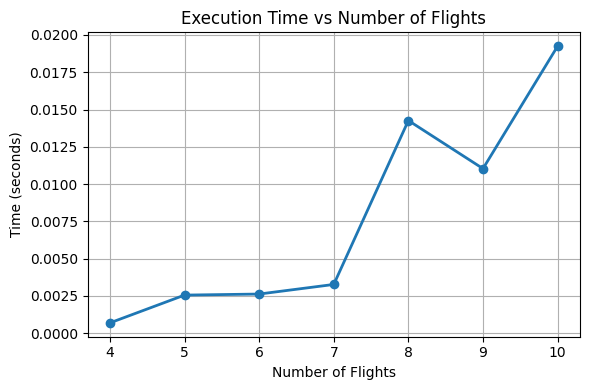

In [ ]:
# -----------------------------------
#  Plot Time vs Flights
# -----------------------------------
plt.figure(figsize=(6, 4))
plt.plot(df["n"], df["time"], marker='o', linewidth=2)
plt.title("Execution Time vs Number of Flights")
plt.xlabel("Number of Flights")
plt.ylabel("Time (seconds)")
plt.grid(True)

plt.savefig(os.path.join(OUT_DIR, "time_vs_flights_rewritten.png"))
plt.show()


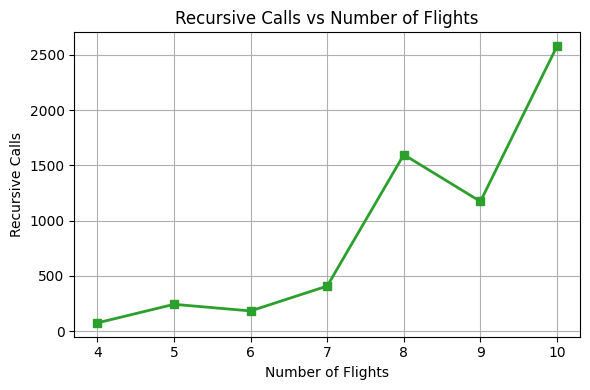

In [ ]:
# -----------------------------------
#  Plot Recursive Calls
# -----------------------------------
plt.figure(figsize=(6, 4))
plt.plot(df["n"], df["calls"], marker='s', color='tab:green', linewidth=2)
plt.title("Recursive Calls vs Number of Flights")
plt.xlabel("Number of Flights")
plt.ylabel("Recursive Calls")
plt.grid(True)

plt.savefig(os.path.join(OUT_DIR, "calls_vs_flights_rewritten.png"))
plt.show()


In [ ]:
def draw_gantt(solution_alloc, times_map, save_to=None):
    fig, ax = plt.subplots(figsize=(8, 4))
    cmap = plt.cm.tab10

    for idx, (crew, flist) in enumerate(solution_alloc.items()):
        for f in flist:
            s, e = times_map[f]
            ax.barh(crew, e - s, left=s, height=0.6,
                    color=cmap(idx % 10), edgecolor='black')
            ax.text(s + (e - s)/2, idx, f,
                    ha="center", va="center", color="white", fontsize=9)

    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Crew Members")
    ax.grid(True, axis='x', linestyle='--', alpha=0.6)

    plt.tight_layout()
    if save_to:
        plt.savefig(save_to, dpi=150)
    plt.show()


Sample flights: [('FL1', 10, 13), ('FL2', 18, 19), ('FL3', 14, 15), ('FL4', 19, 22), ('FL5', 10, 13), ('FL6', 14, 17), ('FL7', 9, 10), ('FL8', 11, 12)]
Total solutions: 216
Sample assignment: {'CR1': ['FL1', 'FL2', 'FL3'], 'CR2': ['FL4', 'FL5', 'FL6'], 'CR3': ['FL7', 'FL8']}


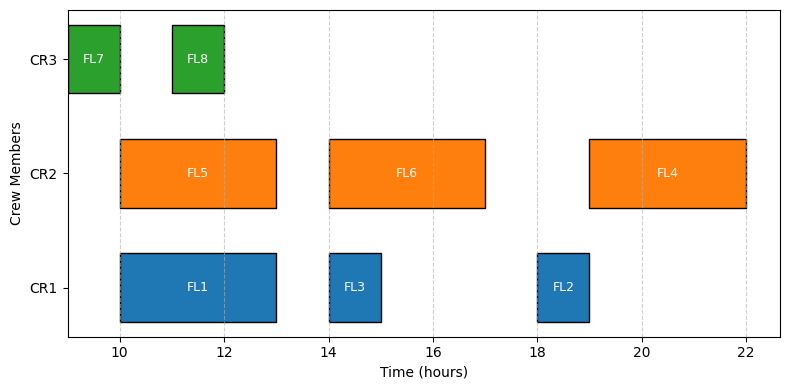

In [ ]:
SAMPLE_N = 8
sample_flights = make_flights_random(SAMPLE_N)
sample_map = {fid: (s, e) for fid, s, e in sample_flights}

stats = {'calls': 0}
sample_solutions = solve_all_assignments(
    {c: [] for c in CREW_LIST},
    [f[0] for f in sample_flights],
    sample_map,
    MIN_REST_HOURS,
    stats
)

with open(os.path.join(OUT_DIR, f"sample_flights_{SAMPLE_N}.json"), "w") as f:
    json.dump(sample_flights, f, indent=2)

print("Sample flights:", sample_flights)
print("Total solutions:", len(sample_solutions))

if sample_solutions:
    best = sample_solutions[0]
    print("Sample assignment:", best)
    draw_gantt(best, sample_map,
               save_to=os.path.join(OUT_DIR, "gantt_sample_rewritten.png"))
else:
    print("No valid assignment (due to overlaps).")
